In [17]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog

# 1. Define our Reactions and Metabolites
# Pathway: Glc -> G6P -> F6P -> F16BP -> 2x GAP -> 2x 3PG -> 2x PEP -> 2x Pyruvate
rxns = ['Uptake', 'HK', 'PGI', 'PFK', 'ALD', 'GAPDH', 'PGM', 'PK', 'Sink']
mets = ['Glc', 'G6P', 'F6P', 'F16BP', 'GAP', '3PG', 'PEP', 'Pyr']

# 2. Build the Stoichiometric Matrix (S)
# Rows = Metabolites, Cols = Reactions
S = np.zeros((len(mets), len(rxns)))

# Mapping stoichiometric coefficients (Negative = consumed, Positive = produced)
# Uptake: -> Glc
S[0, 0] = 1   
# HK: Glc -> G6P
S[0, 1] = -1; S[1, 1] = 1
# PGI: G6P -> F6P
S[1, 2] = -1; S[2, 2] = 1
# PFK: F6P -> F16BP
S[2, 3] = -1; S[3, 3] = 1
#S[0, 0] = -1; S[3, 3] = 1
# ALD: F16BP -> 2 GAP (This is the split!)
#S[3, 4] = -1; S[4, 4] = 2
S[0, 0] = -1; S[4, 4] = 2
# GAPDH: GAP -> 3PG
S[4, 5] = -1; S[5, 5] = 1
# PGM: 3PG -> PEP
S[5, 6] = -1; S[6, 6] = 1
# PK: PEP -> Pyr
S[6, 7] = -1; S[7, 7] = 1
# Sink: Pyr -> Out
S[7, 8] = -1

# 3. Set the Objective (Maximize Pyruvate Output)
# linprog minimizes, so to maximize rxn index 8 (Sink), we use -1
c = np.zeros(len(rxns))
c[8] = -1 

# 4. Set Constraints and Bounds
# Assume steady state: S * v = 0, 
#($dX/dt = 0$) where the production of each metabolite equals its consumption
A_eq = S
b_eq = np.zeros(len(mets))

# Define Flux Bounds: (min, max)
# We limit Glucose Uptake to 10 units. All others are 0 to infinity.
bounds = [(0, 10)] + [(0, None)] * (len(rxns) - 1)

# 5. Solve the Linear Program
res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

# 6. Display Results
if res.success:
    flux_df = pd.DataFrame({'Reaction': rxns, 'Flux (mmol/gDW/h)': res.x})
    print("--- Glycolysis Flux Distribution ---")
    print(flux_df.to_string(index=False))
else:
    print("Optimization failed.")

Optimization failed.


TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

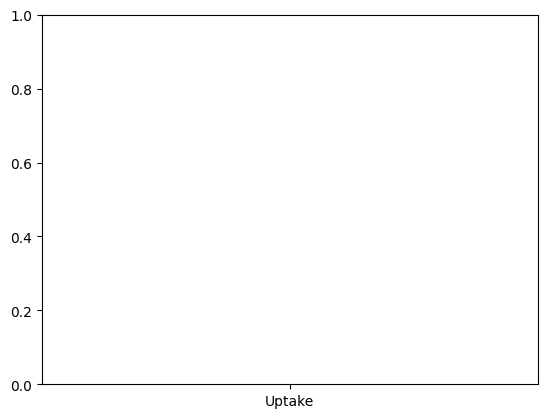

In [18]:
import matplotlib.pyplot as plt

# Using the flux results from the previous script
flux_values = res.x
reactions = ['Uptake', 'HK', 'PGI', 'PFK', 'ALD', 'GAPDH', 'PGM', 'PK', 'Sink']

# Create the bar chart
plt.bar(reactions, flux_values, color=['gray', 'blue', 'blue', 'blue', 'blue', 'green', 'green', 'green', 'green'])
plt.ylabel('Flux ($mmol/gDW/h$)')
plt.title('Predicted Glycolysis Flux (FBA)')
plt.xticks(rotation=45)

# Annotate the split for the class
plt.annotate('Carbon Split', xy=(4, 10), xytext=(2, 15),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.savefig('glycolysis_flux_plot.png')

In [14]:
#1. Visualize the Matrix ($S \cdot v = 0$): 
#Briefly show the stoichiometric matrix ($S$) 
#in your notebook. Point out the "Uptake" and "Sink" 
#columns to show how carbon enters and leaves the 
#system.
#2.since the system is underdetermined, 
#you must tell the model what to "optimize" for. 
# (here I am optimizing for Pyruvate production).
# a more advanced model might optimize for biomass 
# (what would this simulate for?) Growth...
#3. the flux distribution output where the value jumps 
#from 10.0 to 20.0 at the GAPDH step. Why this happens?
#(one 6-carbon glucose splitting into two 3-carbon molecules)
#demonstration
#1. Which enzyme in this glycolysis pathway 
#should I 'delete' (set flux to 0)?
#2. Manually change the bounds of a reaction 
#(e.g., set PFK bounds to (0, 0)) and re-run the 
#linprog solver live.


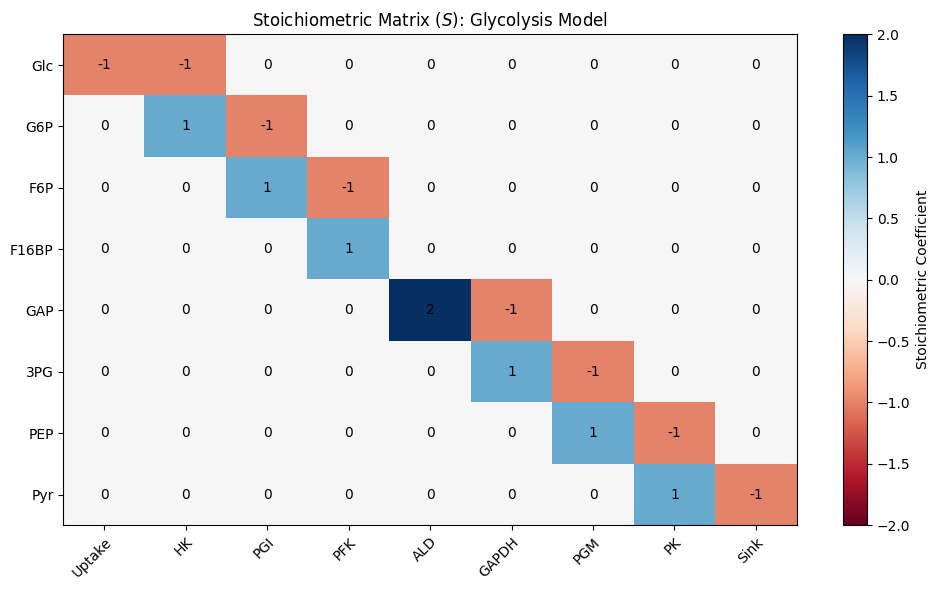

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Create the heatmap using standard Matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(S, cmap='RdBu', aspect='auto', vmin=-2, vmax=2)

# Add colorbar and labels
plt.colorbar(im, label='Stoichiometric Coefficient')
ax.set_xticks(np.arange(len(rxns)))
ax.set_yticks(np.arange(len(mets)))
ax.set_xticklabels(rxns)
ax.set_yticklabels(mets)

# Rotate labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotate each cell with the number
for i in range(len(mets)):
    for j in range(len(rxns)):
        text = ax.text(j, i, int(S[i, j]), ha="center", va="center", color="black")

ax.set_title("Stoichiometric Matrix ($S$): Glycolysis Model")
fig.tight_layout()
plt.show()